step     0 | loss 7.362e-01 | L2 7.084e-01 | L∞ 1.038e+00 | node MSE 4.716e-01 | τ 0.692 | ω -
step   200 | loss 7.250e-01 | L2 7.064e-01 | L∞ 1.079e+00 | node MSE 4.552e-01 | τ 0.733 | ω -
step   400 | loss 7.250e-01 | L2 7.064e-01 | L∞ 1.079e+00 | node MSE 4.552e-01 | τ 0.733 | ω -
step   600 | loss 7.250e-01 | L2 7.064e-01 | L∞ 1.079e+00 | node MSE 4.552e-01 | τ 0.733 | ω -
step   800 | loss 7.250e-01 | L2 7.064e-01 | L∞ 1.079e+00 | node MSE 4.552e-01 | τ 0.733 | ω -
step  1000 | loss 7.250e-01 | L2 7.064e-01 | L∞ 1.079e+00 | node MSE 4.552e-01 | τ 0.733 | ω -
step  1200 | loss 7.250e-01 | L2 7.064e-01 | L∞ 1.079e+00 | node MSE 4.552e-01 | τ 0.733 | ω -
step  1400 | loss 7.250e-01 | L2 7.064e-01 | L∞ 1.079e+00 | node MSE 4.552e-01 | τ 0.733 | ω -
step  1600 | loss 7.250e-01 | L2 7.064e-01 | L∞ 1.079e+00 | node MSE 4.552e-01 | τ 0.733 | ω -
step  1800 | loss 7.250e-01 | L2 7.064e-01 | L∞ 1.079e+00 | node MSE 4.552e-01 | τ 0.733 | ω -
step  2000 | loss 7.250e-01 | L2 7.064e-01 | L∞ 1.

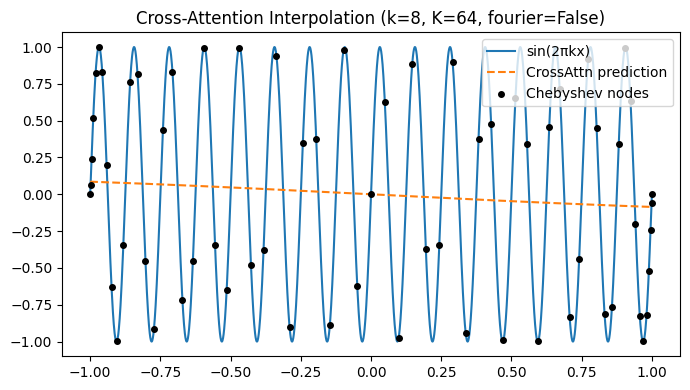

In [1]:
# cross_attention_cheb_interp.py  (updated)
from __future__ import annotations
import math
from dataclasses import dataclass
from typing import Tuple

import jax
import jax.numpy as jnp
from flax import nnx
import optax
from jaxpi.ssbroyden_optax import scale_by_ssbroyden_wolfe_oracle

try:
    import matplotlib.pyplot as plt
    HAVE_PLT = True
except Exception:
    HAVE_PLT = False

jax.config.update("jax_enable_x64", True)
DTYPE = jnp.float64

# --------------------------
# Chebyshev–Lobatto utilities
# --------------------------
def cheb_lobatto_nodes(K: int) -> jnp.ndarray:
    j = jnp.arange(K + 1, dtype=DTYPE)
    return jnp.cos(jnp.pi * j / K)

# --------------------------
# Target function
# --------------------------
def target_sin(x: jnp.ndarray, k: int) -> jnp.ndarray:
    return jnp.sin(2.0 * jnp.pi * k * x)

# --------------------------
# Fourier features φ(x)
# --------------------------
def fourier_features(x: jnp.ndarray, n_freqs: int, omega: DTYPE) -> jnp.ndarray:
    x = x.astype(DTYPE)
    xcol = x[..., None]
    r = jnp.arange(1, n_freqs + 1, dtype=DTYPE)
    angles = 2.0 * jnp.pi * omega * xcol * r  # [..., n_freqs]
    s = jnp.sin(angles)
    c = jnp.cos(angles)
    return jnp.concatenate([xcol, s, c], axis=-1)  # [..., 1 + 2*n_freqs]

# --------------------------
# Cross-Attention Regressor (no MLP head)
# --------------------------
class CrossAttnRegressor(nnx.Module):
    """
    Queries attend to context (keys/values).
    If use_fourier=False, we embed as φ(x)=x (raw coordinate).
    """
    def __init__(
        self,
        n_freqs: int = 16,
        d_model: int = 64,
        use_fourier: bool = True,
        *,
        rngs: nnx.Rngs,
    ):
        self.n_freqs = n_freqs
        self.d_model = d_model
        self.use_fourier = use_fourier

        feat_dim = (1 + 2 * n_freqs) if use_fourier else 1
        self.q_proj = nnx.Linear(feat_dim, d_model, use_bias=True, rngs=rngs)
        self.k_proj = nnx.Linear(feat_dim, d_model, use_bias=True, rngs=rngs)

        # Learnable temperature τ >= 0 via softplus
        self.tau_raw = nnx.Param(jnp.array(0.0, dtype=DTYPE))  # τ = softplus(tau_raw)

        # Learnable Fourier scale only if using Fourier features
        if use_fourier:
            self.log_omega = nnx.Param(jnp.array(0.0, dtype=DTYPE))  # ω init = 1.0

    def _attn_scores(self, q: jnp.ndarray, k: jnp.ndarray) -> jnp.ndarray:
        scale = DTYPE(self.d_model) ** -0.5
        dots = q @ (k.T) * scale  # [N, M]
        tau = jax.nn.softplus(self.tau_raw).astype(DTYPE)
        return tau * dots

    def _embed(self, x: jnp.ndarray) -> jnp.ndarray:
        if self.use_fourier:
            omega = jnp.exp(self.log_omega).astype(DTYPE)
            return fourier_features(x, self.n_freqs, omega)  # [..., 1+2n]
        else:
            return x.astype(DTYPE)[..., None]  # raw x, shape [..., 1]

    def __call__(self, x_query: jnp.ndarray, x_ctx: jnp.ndarray, y_ctx: jnp.ndarray) -> jnp.ndarray:
        phi_q = self._embed(x_query)      # [N, feat_dim]
        phi_k = self._embed(x_ctx)        # [M, feat_dim]

        Q = self.q_proj(phi_q)            # [N, d_model]
        K = self.k_proj(phi_k)            # [M, d_model]

        scores = self._attn_scores(Q, K)  # [N, M]
        alpha = jax.nn.softmax(scores, axis=-1)  # [N, M]
        y_hat = alpha @ y_ctx             # [N]
        return y_hat

# --------------------------
# Training utilities
# --------------------------
@dataclass
class Config:
    K_nodes: int = 64
    k_freq: int = 5
    n_freqs: int = 32
    d_model: int = 64
    use_fourier: bool = True          # <—— toggle here
    lr: float = 3e-3
    steps: int = 4000
    batch_size: int = 256
    recon_lambda: float = 0.5
    seed: int = 42
    eval_N: int = 2001

def make_context(cfg: Config) -> Tuple[jnp.ndarray, jnp.ndarray]:
    x_ctx = cheb_lobatto_nodes(cfg.K_nodes)  # [K+1]
    y_ctx = target_sin(x_ctx, cfg.k_freq)
    return x_ctx, y_ctx

def sample_queries(rng_key, batch_size: int) -> jnp.ndarray:
    return jnp.linspace(-1.0, 1.0, batch_size, dtype=DTYPE)
    return jax.random.uniform(rng_key, (batch_size,), minval=-1.0, maxval=1.0, dtype=DTYPE)

def mse(a: jnp.ndarray, b: jnp.ndarray) -> DTYPE:
    return jnp.mean((a - b) ** 2)

def l2(a: jnp.ndarray, b: jnp.ndarray) -> DTYPE:
    return jnp.sqrt(mse(a, b))

def train(cfg: Config):
    rng = jax.random.PRNGKey(cfg.seed)
    rng, init_key = jax.random.split(rng)

    model = CrossAttnRegressor(
        n_freqs=cfg.n_freqs,
        d_model=cfg.d_model,
        use_fourier=cfg.use_fourier,
        rngs=nnx.Rngs(init_key),
    )
    tx = optax.adam(cfg.lr)
    optim = nnx.Optimizer(model, tx, wrt=nnx.Param)

    x_ctx, y_ctx = make_context(cfg)

    @nnx.jit
    def train_step(model: CrossAttnRegressor, optim: nnx.Optimizer, x_q: jnp.ndarray,
                   x_ctx: jnp.ndarray, y_ctx: jnp.ndarray, recon_lambda: DTYPE):
        def loss_fn(m: CrossAttnRegressor):
            y_q = target_sin(x_q, cfg.k_freq)
            y_hat_q = m(x_q, x_ctx, y_ctx)
            loss_q = mse(y_hat_q, y_q)
            y_hat_ctx = m(x_ctx, x_ctx, y_ctx)
            loss_ctx = mse(y_hat_ctx, y_ctx)
            return loss_q + recon_lambda * loss_ctx

        loss, grads = nnx.value_and_grad(loss_fn)(model)
        optim.update(model, grads)
        return loss

    for step in range(cfg.steps):
        rng, key = jax.random.split(rng)
        x_q = sample_queries(key, cfg.batch_size)
        loss = train_step(model, optim, x_q, x_ctx, y_ctx, DTYPE(cfg.recon_lambda))

        if (step % 200) == 0 or (step == cfg.steps - 1):
            x_eval = jnp.linspace(-1.0, 1.0, cfg.eval_N, dtype=DTYPE)
            y_true = target_sin(x_eval, cfg.k_freq)
            y_pred = model(x_eval, x_ctx, y_ctx)
            err_l2 = l2(y_pred, y_true)
            err_linf = jnp.max(jnp.abs(y_pred - y_true))
            node_mse = mse(model(x_ctx, x_ctx, y_ctx), y_ctx)
            tau = jax.nn.softplus(model.tau_raw)
            # ω only exists if Fourier features are on
            omega = jnp.exp(model.log_omega) if cfg.use_fourier else None
            omega_str = f"{float(omega):.3f}" if omega is not None else "-"
            print(f"step {step:5d} | loss {loss:.3e} | L2 {err_l2:.3e} | L∞ {err_linf:.3e} "
                  f"| node MSE {node_mse:.3e} | τ {float(tau):.3f} | ω {omega_str}")

    x_eval = jnp.linspace(-1.0, 1.0, cfg.eval_N, dtype=DTYPE)
    y_true = target_sin(x_eval, cfg.k_freq)
    y_pred = model(x_eval, x_ctx, y_ctx)
    print("\nFinal metrics:")
    print(f"L2  = {l2(y_pred, y_true):.6e}")
    print(f"L∞  = {jnp.max(jnp.abs(y_pred - y_true)):.6e}")
    print(f"Node MSE = {mse(model(x_ctx, x_ctx, y_ctx), y_ctx):.6e}")

    if HAVE_PLT:
        plt.figure(figsize=(7.0, 4.0))
        plt.plot(x_eval, y_true, label="sin(2πkx)")
        plt.plot(x_eval, y_pred, "--", label="CrossAttn prediction")
        plt.scatter(x_ctx, y_ctx, s=16, c="k", zorder=3, label="Chebyshev nodes")
        plt.title(f"Cross-Attention Interpolation (k={cfg.k_freq}, K={cfg.K_nodes}, fourier={cfg.use_fourier})")
        plt.legend()
        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    # Toggle use_fourier here
    cfg = Config(
        K_nodes=64,
        k_freq=8,
        n_freqs=32,
        d_model=64,
        use_fourier=False,   # <—— set to False to use raw x (no embedding)
        lr=3e-3,
        steps=4000,
        batch_size=256,
        recon_lambda=0.5,
        seed=0,
        eval_N=2001,
    )
    train(cfg)


In [2]:
def rel_l2_error(a: jnp.ndarray, b: jnp.ndarray) -> DTYPE:
    return jnp.linalg.norm(a - b) / (jnp.linalg.norm(b))

def train_with_ssbroyden(cfg: Config):
    """Training function using SSBroyden optimizer similar to softmax_testing.ipynb"""
    # RNGs
    rng = jax.random.PRNGKey(cfg.seed)
    rng, init_key = jax.random.split(rng)

    # Model
    model = CrossAttnRegressor(n_freqs=cfg.n_freqs, d_model=cfg.d_model, rngs=nnx.Rngs(init_key))
    
    # Create the SSBroyden optimizer pipeline
    def make_fg_oracle(graphdef):
        def f(params, x_q, x_ctx, y_ctx, recon_lambda):
            model_tmp = nnx.merge(graphdef, params)  # rebuild a model with these params
            # Supervised queries
            y_q = target_sin(x_q, cfg.k_freq)
            y_hat_q = model_tmp(x_q, x_ctx, y_ctx)
            loss_q = mse(y_hat_q, y_q)
            # Reconstruction at context nodes
            y_hat_ctx = model_tmp(x_ctx, x_ctx, y_ctx)
            loss_ctx = mse(y_hat_ctx, y_ctx)
            return loss_q + recon_lambda * loss_ctx
        # JIT the oracle + take grads w.r.t "params"
        return nnx.jit(nnx.value_and_grad(f, argnums=0))

    tx = scale_by_ssbroyden_wolfe_oracle(lr=1.0, c1=1e-4, c2=0.9, max_ls=20)
    optim = nnx.Optimizer(model, tx, wrt=nnx.Param)

    # Build the oracle once from a static graphdef
    graphdef = nnx.graphdef(model)  # static structure of the Module
    fg_oracle = make_fg_oracle(graphdef)

    # Context (fixed for this run)
    x_ctx, y_ctx = make_context(cfg)

    @nnx.jit
    def train_step_ssbroyden(model, optim, x_q, x_ctx, y_ctx, recon_lambda):
        # grads w.r.t. model Params
        def cur_loss(m):
            y_q = target_sin(x_q, cfg.k_freq)
            y_hat_q = m(x_q, x_ctx, y_ctx)
            loss_q = mse(y_hat_q, y_q)
            y_hat_ctx = m(x_ctx, x_ctx, y_ctx)
            loss_ctx = mse(y_hat_ctx, y_ctx)
            return loss_q + recon_lambda * loss_ctx
        
        f_k, grads = nnx.value_and_grad(cur_loss, argnums=nnx.DiffState(0, nnx.Param))(model)

        # Pass oracle + runtime tensors via **kwargs (forwarded to tx.update)
        optim.update(model, grads, f_k=f_k, fg_oracle=fg_oracle, 
                    loss_args=(x_q, x_ctx, y_ctx, DTYPE(recon_lambda)))
        return f_k

    # Training loop
    for step in range(cfg.steps):
        rng, key = jax.random.split(rng)
        x_q = sample_queries(key, cfg.batch_size)
        loss = train_step_ssbroyden(model, optim, x_q, x_ctx, y_ctx, DTYPE(cfg.recon_lambda))

        if (step % 20) == 0 or (step == cfg.steps - 1):
            # Quick eval on a grid
            x_eval = jnp.linspace(-1.0, 1.0, cfg.eval_N, dtype=DTYPE)
            y_true = target_sin(x_eval, cfg.k_freq)
            y_pred = model(x_eval, x_ctx, y_ctx)
            rel_l2 = rel_l2_error(y_pred, y_true)
            err_linf = jnp.max(jnp.abs(y_pred - y_true))
            node_mse = mse(model(x_ctx, x_ctx, y_ctx), y_ctx)
            tau = jax.nn.softplus(model.tau_raw)
            omega = jnp.exp(model.log_omega)
            print(f"step {step:5d} | loss {loss:.3e} | rel L2 {rel_l2:.3e} | L∞ {err_linf:.3e} "
                  f"| node MSE {node_mse:.3e} | τ {tau:.3f} | ω {omega:.3f}")

    # Final eval & (optional) plot
    x_eval = jnp.linspace(-1.0, 1.0, cfg.eval_N, dtype=DTYPE)
    y_true = target_sin(x_eval, cfg.k_freq)
    y_pred = model(x_eval, x_ctx, y_ctx)
    print("\nFinal metrics (SSBroyden):")
    print(f"rel L2  = {rel_l2_error(y_pred, y_true):.6e}")
    print(f"L∞  = {jnp.max(jnp.abs(y_pred - y_true)):.6e}")
    print(f"Node MSE = {mse(model(x_ctx, x_ctx, y_ctx), y_ctx):.6e}")

    if HAVE_PLT:
        plt.figure(figsize=(7.0, 4.0))
        plt.plot(x_eval, y_true, label="sin(2πkx)")
        plt.plot(x_eval, y_pred, "--", label="CrossAttn prediction (SSBroyden)")
        plt.scatter(x_ctx, y_ctx, s=16, c="k", zorder=3, label="Chebyshev nodes")
        plt.title(f"Cross-Attention Interpolation with SSBroyden (k={cfg.k_freq}, K={cfg.K_nodes})")
        plt.legend()
        plt.tight_layout()
        plt.show()
    
    return model

Training with standard Adam optimizer:
step     0 | loss 9.981e-01 | L2 7.324e-01 | L∞ 1.079e+00 | node MSE 4.573e-01 | τ 0.692 | ω -
step   200 | loss 7.780e-01 | L2 6.659e-01 | L∞ 1.098e+00 | node MSE 3.348e-01 | τ 0.797 | ω -
step   400 | loss 7.780e-01 | L2 6.659e-01 | L∞ 1.098e+00 | node MSE 3.348e-01 | τ 0.797 | ω -
step   600 | loss 7.780e-01 | L2 6.659e-01 | L∞ 1.098e+00 | node MSE 3.348e-01 | τ 0.797 | ω -
step   800 | loss 7.780e-01 | L2 6.659e-01 | L∞ 1.098e+00 | node MSE 3.348e-01 | τ 0.797 | ω -
step  1000 | loss 7.780e-01 | L2 6.659e-01 | L∞ 1.098e+00 | node MSE 3.348e-01 | τ 0.797 | ω -
step  1200 | loss 7.780e-01 | L2 6.659e-01 | L∞ 1.098e+00 | node MSE 3.348e-01 | τ 0.797 | ω -
step  1400 | loss 7.780e-01 | L2 6.659e-01 | L∞ 1.098e+00 | node MSE 3.348e-01 | τ 0.797 | ω -
step  1600 | loss 7.780e-01 | L2 6.659e-01 | L∞ 1.098e+00 | node MSE 3.348e-01 | τ 0.797 | ω -
step  1800 | loss 7.780e-01 | L2 6.659e-01 | L∞ 1.098e+00 | node MSE 3.348e-01 | τ 0.797 | ω -
step  2000 

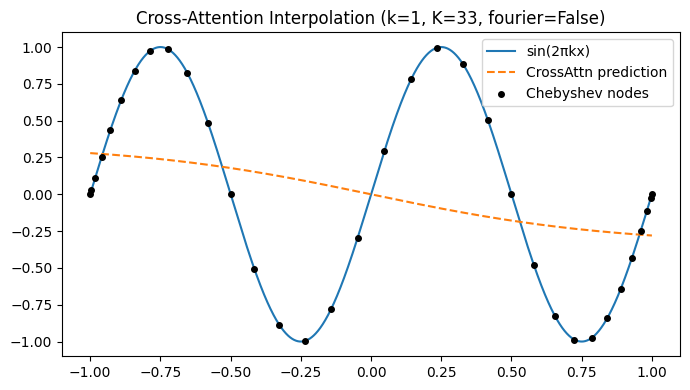


Training with SSBroyden optimizer:
step     0 | loss 9.366e-01 | rel L2 1.001e+00 | L∞ 1.023e+00 | node MSE 4.182e-01 | τ 0.683 | ω 0.627
step    20 | loss 6.784e-01 | rel L2 8.724e-01 | L∞ 1.151e+00 | node MSE 2.982e-01 | τ 0.003 | ω 0.000
step    40 | loss 6.784e-01 | rel L2 8.724e-01 | L∞ 1.151e+00 | node MSE 2.982e-01 | τ 0.003 | ω 0.000
step    60 | loss 6.784e-01 | rel L2 8.724e-01 | L∞ 1.151e+00 | node MSE 2.982e-01 | τ 0.003 | ω 0.000
step    80 | loss 6.784e-01 | rel L2 8.724e-01 | L∞ 1.151e+00 | node MSE 2.982e-01 | τ 0.003 | ω 0.000
step   100 | loss 6.784e-01 | rel L2 8.724e-01 | L∞ 1.151e+00 | node MSE 2.982e-01 | τ 0.003 | ω 0.000
step   120 | loss 6.784e-01 | rel L2 8.724e-01 | L∞ 1.151e+00 | node MSE 2.982e-01 | τ 0.003 | ω 0.000
step   140 | loss 6.784e-01 | rel L2 8.724e-01 | L∞ 1.151e+00 | node MSE 2.982e-01 | τ 0.003 | ω 0.000
step   160 | loss 6.784e-01 | rel L2 8.724e-01 | L∞ 1.151e+00 | node MSE 2.982e-01 | τ 0.003 | ω 0.000
step   180 | loss 6.784e-01 | rel L2 

KeyboardInterrupt: 

In [3]:
# Example usage: Compare Adam vs SSBroyden training
if __name__ == "__main__":
    cfg = Config(
        K_nodes=33,      # K => K+1 nodes
        k_freq=1,        # try different frequencies (e.g., 2, 4, 8, 12)
        n_freqs=32,
        d_model=64,
        lr=3e-3,
        steps=4000,      # Reduced steps for faster comparison
        batch_size=1024,
        recon_lambda=1.0,
        seed=0,
        eval_N=2001,
        use_fourier=False
    )
    
    print("=" * 60)
    print("Training with standard Adam optimizer:")
    print("=" * 60)
    model_adam = train(cfg)
    
    print("\n" + "=" * 60)
    print("Training with SSBroyden optimizer:")
    print("=" * 60)
    model_ssbroyden = train_with_ssbroyden(cfg)